#### Fractional Diferentiation

When you calculate standard log returns, you are applying the first-order difference operator $\Delta X_t = X_t - X_{t-1}$. In signal processing, this acts as a severe high-pass filter. It removes the low-frequency components of the signal—which is exactly where the long-term cointegrating relationship (the "harmonic spring") resides.

Fractional differentiation, introduced to quantitative finance by Marcos López de Prado, applies a fractional filter that makes the series stationary (finite variance, constant mean) while mathematically preserving the low-frequency spectral memory of the underlying price path.

The backshift operator $B$, where $B^k X_t = X_{t-k}$, allows us to define the fractional difference operator for a real number $d$:$$(1-B)^d = \sum_{k=0}^{\infty} \omega_k B^k$$Where the weights $\omega_k$ are derived via the Gamma function:$$\omega_k = (-1)^k \binom{d}{k} = \prod_{i=1}^k \frac{i - 1 - d}{i}$$


In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.feature_selection import mutual_info_regression
import warnings

warnings.filterwarnings("ignore")

def get_ffd_weights(d: float, thres: float) -> np.ndarray:
    """Generates fractional differentiation weights up to a threshold."""
    w, k = [1.], 1
    while True:
        w_ = -w[-1] / k * (d - k + 1)
        if abs(w_) < thres:
            break
        w.append(w_)
        k += 1
    return np.array(w[::-1]).reshape(-1, 1)

def frac_diff_ffd(series: pd.Series, d: float, thres: float = 1e-4) -> pd.Series:
    """Applies Fractional Differentiation (Fixed-Window) to a Pandas Series."""
    w = get_ffd_weights(d, thres)
    width = len(w) - 1
    df_ = pd.Series(index=series.index, dtype=float)
    
    # Vectorized dot product over a rolling window
    for i in range(width, len(series)):
        window = series.iloc[i - width : i + 1].values
        if np.isfinite(window).all():
            df_.iloc[i] = np.dot(w.T, window)[0]
            
    return df_.dropna()

# 1. Fetch Data
print("Fetching KO and PEP daily log-prices...")
data = yf.download(['KO', 'PEP'], start='2015-01-01', end='2024-01-01', auto_adjust=False)['Adj Close']
log_prices = np.log(data).dropna()

# 2. Integer Differentiation (Log Returns, d=1)
returns = log_prices.diff().dropna()

# 3. Fractional Differentiation (d=0.4)
# Note: In production, d must be dynamically optimized via ADF test. 0.4 is chosen heuristically here.
print("Applying Fractional Differentiation (d=0.4)...")
frac_diff_KO = frac_diff_ffd(log_prices['KO'], d=0.4)
frac_diff_PEP = frac_diff_ffd(log_prices['PEP'], d=0.4)

# Align the fractionally differenced series
frac_diff_df = pd.concat([frac_diff_KO, frac_diff_PEP], axis=1).dropna()
frac_diff_df.columns = ['KO', 'PEP']

# 4. Calculate Mutual Information (KSG Estimator)
# We calculate MI(X, Y) using k=3 nearest neighbors
mi_returns = mutual_info_regression(returns[['KO']].values, returns['PEP'].values, n_neighbors=3, random_state=42)[0]
mi_frac = mutual_info_regression(frac_diff_df[['KO']].values, frac_diff_df['PEP'].values, n_neighbors=3, random_state=42)[0]

print("-" * 50)
print(f"Mutual Information (Log Returns, d=1.0):      {mi_returns:.4f} nats")
print(f"Mutual Information (Frac. Differenced, d=0.4): {mi_frac:.4f} nats")
print(f"Information Gained by Preserving Memory:       {((mi_frac - mi_returns) / mi_returns) * 100:.2f}%")
print("-" * 50)

Fetching KO and PEP daily log-prices...


[*********************100%***********************]  2 of 2 completed


Applying Fractional Differentiation (d=0.4)...
--------------------------------------------------
Mutual Information (Log Returns, d=1.0):      0.4667 nats
Mutual Information (Frac. Differenced, d=0.4): 0.6427 nats
Information Gained by Preserving Memory:       37.71%
--------------------------------------------------


#### Probabilidad conjunta

Observamos que según la derivada aplicada, cambia la estructura de la distribución de probabilidad.

A ambos pares de variables le realizamos una transformación y analizamos el Z-score.

$$z_t = \frac{\tilde{X}_t - \text{E}[\tilde{X}]}{\sqrt{\text{Var}(\tilde{X})}}$$

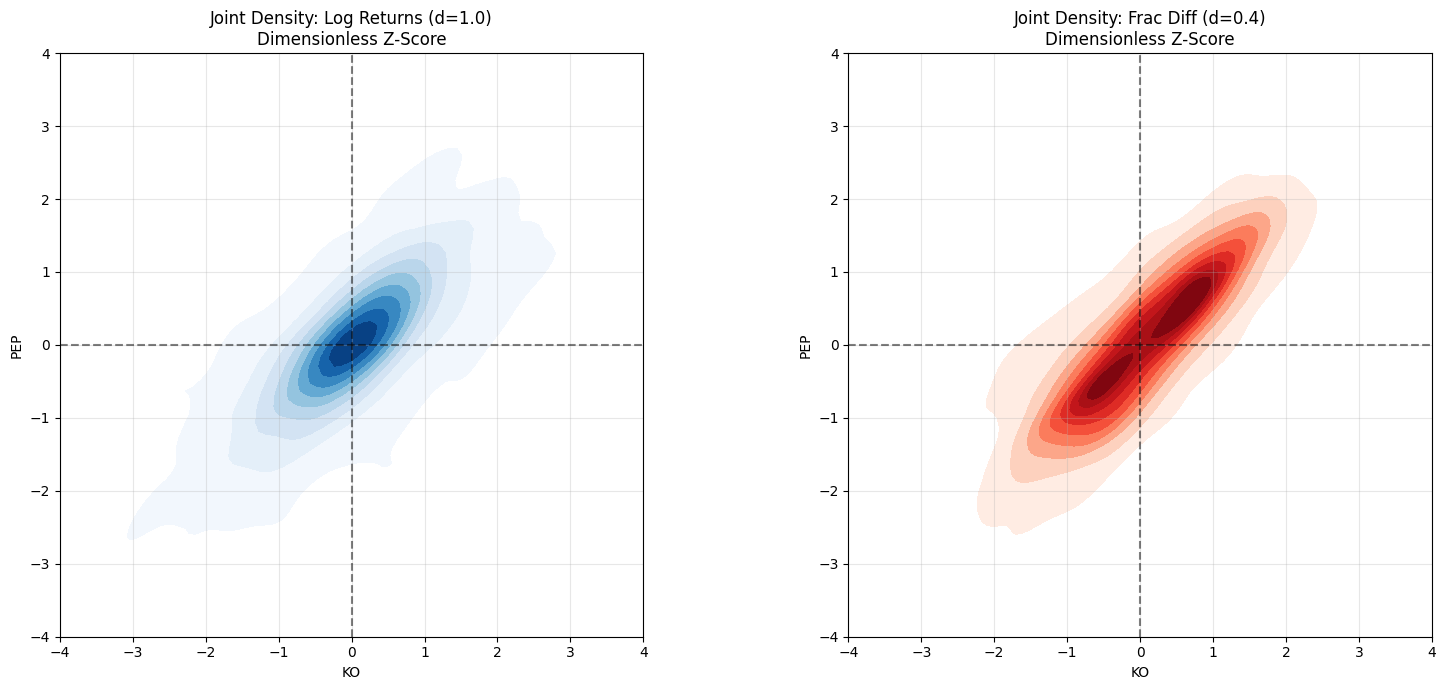

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler

def visualize_mi_manifold_zscored(df_returns, df_frac, pair=('KO', 'PEP')):
    """
    Diagnostic tool to compare the information density of returns vs fractional diff,
    using dimensionless Z-scores to ensure an unbiased topological representation.
    """
    # 1. Initialize the Standard Scaler
    scaler = StandardScaler()
    
    # Extract the pair and drop NaNs to avoid scaler errors
    data_returns = df_returns[list(pair)].dropna()
    data_frac = df_frac[list(pair)].dropna()
    
    # 2. Calculate Z-scores for Log Returns
    returns_scaled = scaler.fit_transform(data_returns)
    df_returns_z = pd.DataFrame(returns_scaled, columns=pair, index=data_returns.index)
    
    # 3. Calculate Z-scores for Fractionally Differenced Prices
    frac_scaled = scaler.fit_transform(data_frac)
    df_frac_z = pd.DataFrame(frac_scaled, columns=pair, index=data_frac.index)

    # 4. Create the Diagnostic Dashboard
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # --- Plot 1: Log Returns (Z-Scored) ---
    sns.kdeplot(data=df_returns_z, x=pair[0], y=pair[1], ax=axes[0], 
                cmap="Blues", fill=True, thresh=0.05, 
                bw_method='silverman')  # Enforce objective bandwidth selection
    
    
    # Force 1:1 aspect ratio to prevent optical distortion
    axes[0].set_aspect('equal', adjustable='box')
    axes[0].axhline(0, color='black', linestyle='--', alpha=0.5)
    axes[0].axvline(0, color='black', linestyle='--', alpha=0.5)
    axes[0].set_title(f"Joint Density: Log Returns (d=1.0)\nDimensionless Z-Score")
    axes[0].grid(alpha=0.3)
    axes[0].set_xlim(-4, 4)
    axes[0].set_ylim(-4, 4)

    
    # --- Plot 2: Fractional Differentiation (Z-Scored) ---
    sns.kdeplot(data=df_frac_z, x=pair[0], y=pair[1], ax=axes[1], 
                cmap="Reds", fill=True, thresh=0.05, 
                bw_method='silverman')
    
    # Force 1:1 aspect ratio
    axes[1].set_aspect('equal', adjustable='box')
    axes[1].axhline(0, color='black', linestyle='--', alpha=0.5)
    axes[1].axvline(0, color='black', linestyle='--', alpha=0.5)
    axes[1].set_title(f"Joint Density: Frac Diff (d=0.4)\nDimensionless Z-Score")
    axes[1].grid(alpha=0.3)
    axes[1].set_xlim(-4, 4)
    axes[1].set_ylim(-4, 4)
    
    plt.tight_layout()
    plt.show()

# Usage Example:
visualize_mi_manifold_zscored(returns, frac_diff_df, pair=('KO', 'PEP'))
